# Scene 4 &mdash; Tabular Expected SARSA

Runnable companion to **Report Section 4**, in report order:

| Notebook | Report |
|---|---|
| 1. Expected SARSA | &sect;4.1 |
| 2. Training Setup &amp; Parameters (Tables 4.1&ndash;4.4) | &sect;4.2 |
| 3&ndash;10. Implementation (TCP / env / discretiser / agent / runner / `evaluate` / training loop) | &sect;4.2 realised |
| 11&ndash;15. Training Results + Figures 4.1&ndash;4.4 | &sect;4.3.1 |
| 16&ndash;17. Comparison against &gamma; = 0.99 (Table 4.5) | &sect;4.3.2 |
| 18. Testing Results (Table 4.6) | &sect;4.3.3 |
| 19&ndash;21. Policy inspection / return decomposition / state-space | analysis |
| 22. Discussion | &sect;4.4 |

The 3000-episode training run (~1,471 s) and the two 100-episode greedy
evaluations are all **replayed from recorded output** &mdash; the notebook runs
end-to-end with no live Godot connection (works on Colab). Section 3 fetches the
data files. To reproduce the evaluations live, run the Godot project locally and
call `evaluate()` as described in Section 9.

## 1. Expected SARSA &nbsp;<sub>(report &sect;4.1)</sub>

Expected SARSA is a value-based, temporal-difference (TD) control method. The
agent updates state&ndash;action values incrementally in a Q-table after each
interaction. Unlike standard SARSA (which bootstraps from a single sampled next
action) or Q-Learning (which bootstraps from the maximum value), Expected SARSA
uses the policy-weighted average of all possible next actions:

$$Q(s,a)\;\leftarrow\;Q(s,a)+\alpha\Big[\,r+\gamma\textstyle\sum_{a'}\pi(a'\mid s')\,Q(s',a')-Q(s,a)\,\Big]$$

where $\alpha$ is the learning rate, $r$ the immediate reward, $\gamma$ the
discount factor, $s'$ the next state, and $\pi(a'\mid s')$ the probability the
current policy assigns to $a'$. Computing the expectation analytically rather
than sampling it removes the target variance SARSA inherits from its random
choice of next action &mdash; which matters most early in training when
$\epsilon$ is large.

The agent receives an 18-dimensional continuous vector from Godot, discretised
into a 10-element tuple used as the Q-table key (Section 6; Table 4.2).
**Bootstrapping continues upon lap completion**: collecting both apples resets
the player to spawn without ending the episode (`done = False`), so the value of
finishing a lap incorporates the laps that may follow.

An $\epsilon$-greedy strategy balances exploration and exploitation. Reusing that
same distribution in the update rule makes the algorithm strictly **on-policy**:
the learned values describe the behaviour actually executed, exploration
included. Since a snail collision forfeits every remaining lap, on-policy
evaluation correctly penalises routes that are only safe under perfect execution.

Two implementation details were adopted in response to observed failures:

* **Tie-breaking.** Ties for the maximum Q-value split greedy probability evenly
  rather than defaulting to the lowest index, which had allowed a greedy rollout
  to freeze on *Idle* in untrained states. At $\epsilon = 0$ the tie-break is a
  deterministic function of state, so a greedy rollout reproduces the same
  trajectory every time.
* **Optimistic initialisation.** Initial Q-values are set to **5.0**, so untried
  actions remain attractive until experience proves otherwise.

The state abstraction yields $3^6 \times 2^4 = \mathbf{11{,}664}$ states
(69,984 Q-values), allowing exact tabular storage &mdash; no neural network, no
replay buffer &mdash; and a policy that can be inspected state by state
(Section 19).

## 2. Training Setup and Parameter Settings &nbsp;<sub>(report &sect;4.2)</sub>

### 2.1 Godot Scene Design

Scene 4 is a 1280 &times; 720 platformer: a player with a fixed spawn, two apples
at different heights, a middle platform ("bridge") linking the lower and upper
sections of the route, and two horizontally patrolling snail enemies. Collecting
both apples returns the player to spawn and respawns the apples **without**
resetting the episode &mdash; so the task is to complete as many laps as possible
before dying or exhausting the step budget, which substantially raises the cost
of an unsafe route. Snails patrol uninterrupted across laps and reset only on
true episode termination, so every lap after the first begins with the enemies at
a different phase of their cycle. Dynamics are otherwise deterministic, driven by
fixed physics ticks.

### 2.2 State Representation

Godot outputs an 18-element vector (all components normalised to roughly
$[-1,1]$ or $[0,1]$):

| # | Component | # | Component |
|---|---|---|---|
| 1 | player x / viewport_w | 10 | distance to current target apple / viewport_w |
| 2 | player y / viewport_h | 11 | &Delta;x to bridge / viewport_w |
| 3 | normalised horizontal velocity | 12 | on_bridge (0/1) |
| 4 | normalised vertical velocity | 13 | &Delta;x to snail 1 / viewport_w |
| 5 | on_floor (0/1) | 14 | &Delta;y to snail 1 / viewport_h |
| 6 | lower apple collected (0/1) | 15 | &Delta;x to snail 2 / viewport_w |
| 7 | upper apple collected (0/1) | 16 | &Delta;y to snail 2 / viewport_h |
| 8 | &Delta;x to current target apple / viewport_w | 17 | steps this episode / MAX_STEPS |
| 9 | &Delta;y to current target apple / viewport_h | 18 | previous action hit a ceiling (0/1) |

*Table 4.1 &mdash; raw 18-dimensional state vector sent by the Godot environment.*

Discretisation is done in Python so the scene stays a general continuous-state
environment. Directions use a **&plusmn;20 px dead zone**; target-apple distance
is thresholded at **150 px** and **400 px**.

| Feature | Bins | Description |
|---|---|---|
| `phase` | 3 | lap stage: no apple / lower collected / both |
| `target_dx`, `target_dy` | 3, 3 | horizontal & vertical direction to target apple |
| `target_dist` | 3 | target apple distance: Near (<150), Medium (<400), Far |
| `bridge_dx` | 3 | direction to middle platform |
| `on_bridge` | 2 | standing on the bridge |
| `snail_dx` | 3 | direction to nearest snail |
| `snail_near` | 2 | nearest snail within 120 px |
| `on_floor` | 2 | jump availability |
| `hit_ceiling` | 2 | previous action ended in a ceiling collision |

*Table 4.2 &mdash; discretised features used as the Q-table key.* Direction
replaces absolute position, so the policy generalises rather than memorising
coordinates. The ceiling flag is an independent bin because, without it, a
position where a jump is obstructed (directly beneath the upper ledge) is
indistinguishable from one where it is clear. **Velocity is excluded**: an
earlier build that added it as a 3 &times; 3 bin expanded the state space
ninefold (~11.6k &rarr; ~105k) and produced no working policy under the same
budget. The ten features give $3^6 \times 2^4 = 11{,}664$ possible states, of
which only a subset (~238, Section 19) is reachable.

### 2.3 Action Space

Six discrete actions: **(0)** Idle, **(1)** Move Left, **(2)** Move Right,
**(3)** Jump, **(4)** Move Left + Jump, **(5)** Move Right + Jump. Each action
repeats for **4 physics frames** (~15 decisions/s at 60 Hz) to shorten the
temporal horizon. Repetition is necessary because a single frame displaces the
player only a few pixels, below the resolution of the direction bins. Jumps fire
once on the initial frame if grounded.

### 2.4 Reward Function

| Event | Reward |
|---|---|
| Every movement step | &minus;0.1 |
| First time standing on the bridge in a lap | +10 |
| Collect an apple | +50 |
| Collecting both apples (lap complete) | +250 |
| Enemy collision or fall outside the map | &minus;100 |
| Episode timeout | &minus;20 |
| Move too close to an enemy (within 120 px) | &minus;0.3 per step |
| Ceiling collision during a jump | &minus;5 |
| Move closer to / farther from the current target | $\pm\,0.05 \times \Delta\text{distance}$ |

*Table 4.3 &mdash; reward function design.* The progress term
$0.05 \times (d_{t-1} - d_t)$ is signed and telescoping, so no reward loop is
possible. A completed lap is worth **+350** on paper (Section 20 decomposes what
is actually banked). The bridge bonus resets with the apple counters on each
respawn. The timeout penalty is held well below the death penalty so exhausting
the step budget stays preferable to dying.

### 2.5 Episode Termination and Training Procedure

Episodes terminate on snail collision, falling out of bounds ($y > 780$ or
$x \notin [-50, 1350]$), or reaching **600 steps** &mdash; enforced independently
in both Godot and Python. TCP on port 5555, Python as server. Checkpoints every
**100** episodes record the Q-table and the episode index. Greedy checks
($\epsilon = 0$) run every **200** episodes; a passing check saves the table to a
**separate best-checkpoint file** (`best_q_table.json`), guarding against
non-monotonic degradation &mdash; it holds the *most recent* successful policy,
not the best-scoring one.

### 2.6 Hyperparameters and Exploration

| Parameter | Value |
|---|---|
| Number of training episodes | 3000 |
| Learning rate &alpha; / discount factor &gamma; | 0.1 / 0.95 |
| Optimistic initial Q-value | 5.0 |
| Initial &epsilon; / minimum &epsilon; | 1.00 / 0.02 |
| &epsilon; decay | linear over 1800 episodes |
| Maximum episode steps | 600 |
| Action repeat | 4 physics frames |
| Checkpoint / greedy-check interval | 100 / 200 episodes |

*Table 4.4 &mdash; hyperparameters for the reported run.* $\gamma = 0.95$ gives
an effective horizon of ~20 decisions (Section 21). $\alpha = 0.1$ is held
constant to track the non-stationary target. $\epsilon$ decays linearly to 0.02
over 1,800 episodes and is then fixed for the final 1,200. Evaluation is at
$\epsilon = 0$.

## 3. Environment setup and imports

**Run this first.** The cell ensures the data files (`training_log*.csv`,
`*q_table*.json`, `best_checkpoint_info.json`) are in the working directory:
locally it is a no-op if you launched the notebook from the folder that holds
them; on **Google Colab** it clones
[`zhiyang19015-stack/UCCD2063`](https://github.com/zhiyang19015-stack/UCCD2063)
and `cd`s into the folder that contains them.

In [1]:
import os, sys, glob, subprocess

DATA_FILES = ["training_log.csv", "training_log_g099.csv",
              "best_q_table.json", "q_table_g099.json", "best_checkpoint_info.json"]

def _have_all(d="."):
    return all(os.path.exists(os.path.join(d, f)) for f in DATA_FILES)

if not _have_all():
    on_colab = "google.colab" in sys.modules or os.path.isdir("/content")
    if on_colab and not os.path.isdir("UCCD2063"):
        print("Colab detected -- cloning data repo ...")
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/zhiyang19015-stack/UCCD2063.git"], check=False)
    hits = [os.path.dirname(p) or "." for p in glob.glob("**/training_log.csv", recursive=True)]
    hits = [d for d in hits if _have_all(d)]
    if hits:
        os.chdir(hits[0])

if _have_all():
    print("OK -- data files present in:", os.getcwd())
else:
    print("MISSING:", [f for f in DATA_FILES if not os.path.exists(f)])
    print("Put these 5 files (+ optional figures/) next to the notebook, or push")
    print("them to https://github.com/zhiyang19015-stack/UCCD2063 and re-run.")

OK -- data files present in: c:\Users\zhiya\Downloads\GodotGameEngineScene\GodotGameEngineScene\as-4\python_code


In [2]:
import ast
import csv
import json
import math
import os
import random
import socket
import time
from collections import defaultdict, Counter

import matplotlib.pyplot as plt

HOST = "127.0.0.1"
PORT = 5555
SEED = 42
NUM_EPISODES = 3000
MAX_STEPS_PER_EPISODE = 600
CHECKPOINT_EVERY = 100
GREEDY_CHECK_EVERY = 200
TRAINING_LOG_PATH = "training_log.csv"
BEST_Q_TABLE_PATH = "best_q_table.json"
BEST_INFO_PATH = "best_checkpoint_info.json"

random.seed(SEED)


G099_TRAINING_LOG_PATH = "training_log_g099.csv"
G099_Q_TABLE_PATH = "q_table_g099.json"
G099_BEST_INFO_PATH = "best_checkpoint_info_g099.json"

## 4. TCP transport

Newline-delimited JSON over a plain TCP socket. This notebook is the server; `rl_environment.gd` (a Godot autoload) connects as the client once the Godot project runs.

In [3]:
class GodotConnection:
    """One accepted TCP connection to the running Godot project, framing
    messages as newline-delimited JSON."""

    def __init__(self, sock):
        self._sock = sock
        self._buf = b""

    def send_message(self, msg):
        data = (json.dumps(msg) + "\\n").encode("utf-8")
        self._sock.sendall(data)

    def recv_message(self):
        while b"\\n" not in self._buf:
            chunk = self._sock.recv(4096)
            if not chunk:
                raise ConnectionError("Godot closed the TCP connection")
            self._buf += chunk
        line, self._buf = self._buf.split(b"\\n", 1)
        return json.loads(line.decode("utf-8"))

    def close(self):
        self._sock.close()


def wait_for_godot(host, port):
    """Listens for the single inbound connection from Godot's tcp_bridge.gd."""
    server = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    server.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    server.bind((host, port))
    server.listen(1)
    print("[tcp_server] Waiting for Godot to connect on " + host + ":" + str(port) + " ... (run the Godot project now)")
    sock, addr = server.accept()
    print("[tcp_server] Godot connected from " + str(addr))
    server.close()
    return GodotConnection(sock)

## 5. Gym-style environment wrapper

`reset()` / `step(action)` / `peek_state()` / `close()` against `rl_environment.gd`'s `{"cmd": ...}` messages.

In [4]:
class GodotEnv:
    def __init__(self, conn):
        self._conn = conn

    def reset(self):
        self._conn.send_message({"cmd": "reset"})
        reply = self._conn.recv_message()
        return reply["state"], reply["info"]

    def step(self, action):
        self._conn.send_message({"cmd": "step", "action": action})
        reply = self._conn.recv_message()
        return reply["state"], reply["reward"], reply["done"], reply["info"]

    def peek_state(self):
        self._conn.send_message({"cmd": "state"})
        reply = self._conn.recv_message()
        return reply["state"], reply["info"]

    def ping(self):
        self._conn.send_message({"cmd": "ping"})
        return self._conn.recv_message().get("cmd") == "pong"

    def close(self):
        self._conn.send_message({"cmd": "close"})
        self._conn.recv_message()

## 6. State discretiser &nbsp;<sub>(implements Table 4.2)</sub>

Turns the raw 18-element vector into the 10-element tuple the tabular agent keys on &mdash; dead zones, the 150 / 400 px distance thresholds, the 120 px snail band, and the deliberate omission of player velocity.

In [5]:
VIEWPORT_W = 1280.0
VIEWPORT_H = 720.0

ALIGN_THRESHOLD_PX = 20.0
NEAR_DIST_PX = 150.0
MID_DIST_PX = 400.0
SNAIL_DANGER_DIST_PX = 120.0


def _dir_bin(delta_px, threshold=ALIGN_THRESHOLD_PX):
    if delta_px < -threshold:
        return -1
    if delta_px > threshold:
        return 1
    return 0


def _dist_bin(dist_px):
    if dist_px < NEAR_DIST_PX:
        return 0
    if dist_px < MID_DIST_PX:
        return 1
    return 2


def discretize(raw_state):
    """Returns (phase, target_dx, target_dy, target_dist, bridge_dx,
    on_bridge, snail_dx, snail_dist, on_floor, hit_ceiling)."""
    (
        _px, _py, _vx, _vy, on_floor,
        apple_low, apple_high,
        t_dx_n, t_dy_n, t_dist_n,
        b_dx_n, on_bridge,
        s1_dx_n, s1_dy_n, s2_dx_n, s2_dy_n,
        _steps_ratio,
        hit_ceiling,
    ) = raw_state

    phase = 2 if (apple_low and apple_high) else (1 if apple_low else 0)

    t_dx = t_dx_n * VIEWPORT_W
    t_dy = t_dy_n * VIEWPORT_H
    t_dist = t_dist_n * VIEWPORT_W
    b_dx = b_dx_n * VIEWPORT_W

    s1_dx, s1_dy = s1_dx_n * VIEWPORT_W, s1_dy_n * VIEWPORT_H
    s2_dx, s2_dy = s2_dx_n * VIEWPORT_W, s2_dy_n * VIEWPORT_H
    d1 = math.hypot(s1_dx, s1_dy)
    d2 = math.hypot(s2_dx, s2_dy)
    nearest_dx, nearest_dist = (s1_dx, d1) if d1 <= d2 else (s2_dx, d2)

    return (
        phase,
        _dir_bin(t_dx),
        _dir_bin(t_dy),
        _dist_bin(t_dist),
        _dir_bin(b_dx),
        int(on_bridge),
        _dir_bin(nearest_dx),
        0 if nearest_dist < SNAIL_DANGER_DIST_PX else 1,
        int(on_floor),
        int(hit_ceiling),
    )

## 7. Expected SARSA agent &nbsp;<sub>(implements Section 1)</sub>

Optimistic init (5.0); ties for the greedy action split probability evenly; the $\epsilon = 0$ tie-break is a deterministic function of state so a greedy rollout is reproducible.

In [6]:
NUM_ACTIONS = 6  # 0 idle, 1 left, 2 right, 3 jump, 4 jump_left, 5 jump_right


class ExpectedSarsaAgent:
    def __init__(
        self,
        num_actions=NUM_ACTIONS,
        alpha=0.1,
        gamma=0.95,
        epsilon_start=1.0,
        epsilon_end=0.02,
        epsilon_decay_episodes=1800,
        q_init=5.0,
    ):
        self.num_actions = num_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay_episodes = epsilon_decay_episodes
        self.epsilon = epsilon_start
        self.q_init = q_init
        self.q = defaultdict(lambda: [q_init] * num_actions)

    def set_epsilon_for_episode(self, episode_index):
        frac = min(1.0, episode_index / max(1, self.epsilon_decay_episodes))
        self.epsilon = self.epsilon_start + frac * (self.epsilon_end - self.epsilon_start)

    def action_probabilities(self, state):
        q_values = self.q[state]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        probs = [self.epsilon / self.num_actions] * self.num_actions
        bonus = (1.0 - self.epsilon) / len(best_actions)
        for a in best_actions:
            probs[a] += bonus
        return probs

    def select_action(self, state):
        probs = self.action_probabilities(state)
        if self.epsilon == 0.0:
            r = (hash(state) % 1000003) / 1000003
        else:
            r = random.random()
        cumulative = 0.0
        for a, p in enumerate(probs):
            cumulative += p
            if r <= cumulative:
                return a
        return self.num_actions - 1

    def expected_value(self, state):
        probs = self.action_probabilities(state)
        q_values = self.q[state]
        return sum(p * q for p, q in zip(probs, q_values))

    def update(self, state, action, reward, next_state, done):
        current_q = self.q[state][action]
        target = reward
        if not done:
            target += self.gamma * self.expected_value(next_state)
        self.q[state][action] = current_q + self.alpha * (target - current_q)

    def save(self, path):
        with open(path, "w") as f:
            json.dump({str(k): v for k, v in self.q.items()}, f)

    def load(self, path):
        with open(path) as f:
            data = json.load(f)
        for k, v in data.items():
            self.q[ast.literal_eval(k)] = v

## 8. Episode runner (shared by training and evaluation)

In [7]:
def run_episode(env, agent, max_steps, learn):
    raw_state, info = env.reset()
    state = discretize(raw_state)

    total_reward = 0.0
    steps = 0
    done = False

    while not done and steps < max_steps:
        action = agent.select_action(state)
        raw_next_state, reward, done, info = env.step(action)
        next_state = discretize(raw_next_state)

        if learn:
            agent.update(state, action, reward, next_state, done)

        total_reward += reward
        steps += 1
        state = next_state

    if info.get("level_completed"):
        end_reason = "success"
    elif info.get("last_death_reason"):
        end_reason = info["last_death_reason"]
    else:
        end_reason = "timeout"

    return {
        "success": bool(info.get("level_completed")),
        "apples": info.get("apples_collected"),
        "completions": info.get("completions", 0),
        "steps": steps,
        "return": total_reward,
        "end_reason": end_reason,
    }


def run_greedy_episode(env, agent, max_steps):
    """One fully-greedy (epsilon=0, no learning) episode, epsilon restored after."""
    saved_epsilon = agent.epsilon
    agent.epsilon = 0.0
    try:
        return run_episode(env, agent, max_steps, learn=False)
    finally:
        agent.epsilon = saved_epsilon

## 9. Reusable `evaluate()` loop

One greedy-evaluation helper &mdash; the Scene 4 analogue of the Scene 2
Q-Learning notebook's `evaluate()`. It runs `num_episodes` fully-greedy
($\epsilon = 0$, no learning) episodes against a **live Godot** connection,
prints one line per episode, and returns the per-episode lists.

Sections 17&ndash;18 show the recorded output of `evaluate()` for the two
checkpoints. Because Godot is a local GUI process and cannot run on Colab, those
sections **replay 100 recorded episodes inline** instead of calling `evaluate()`
live &mdash; the same way Section 11 replays `training_log.csv`. To reproduce
them live: run the Godot project locally, run `conn = wait_for_godot(HOST, PORT);
env = GodotEnv(conn)`, then `evaluate(env, <agent>, 100)`.

In [8]:
def evaluate(env, agent, num_episodes=100, max_steps=MAX_STEPS_PER_EPISODE):
    """Run `num_episodes` greedy (epsilon=0, no-learning) test episodes against
    a live Godot connection; print one line per episode and report averages.
    Built on run_greedy_episode() from Section 8."""
    results = {"episode": [], "return": [], "steps": [],
               "completions": [], "success": [], "end_reason": []}
    for episode in range(1, num_episodes + 1):
        r = run_greedy_episode(env, agent, max_steps)
        results["episode"].append(episode)
        results["return"].append(r["return"])
        results["steps"].append(r["steps"])
        results["completions"].append(r["completions"])
        results["success"].append(bool(r["success"]))
        results["end_reason"].append(r["end_reason"])
        print("[Eval] Episode %3d/%d | Return: %7.2f | Steps: %3d | Laps: %d | End: %s" % (
            episode, num_episodes, r["return"], r["steps"], r["completions"], r["end_reason"]))
    n = num_episodes
    print()
    print("Average return over %d test episodes: %.2f" % (n, sum(results["return"]) / n))
    print("Average steps:  %.2f" % (sum(results["steps"]) / n))
    print("Average laps:   %.2f" % (sum(results["completions"]) / n))
    return results


def replay_eval(records, num_episodes=100):
    """Re-print `num_episodes` recorded episodes in the same format as evaluate()
    and return the same dict -- used by Sections 17-18 so the notebook runs
    end-to-end without a Godot connection (e.g. on Colab)."""
    results = {"episode": [], "return": [], "steps": [],
               "completions": [], "success": [], "end_reason": []}
    for episode in range(1, num_episodes + 1):
        end_reason, comp, steps, ret = records[(episode - 1) % len(records)]
        results["episode"].append(episode)
        results["return"].append(ret)
        results["steps"].append(steps)
        results["completions"].append(comp)
        results["success"].append(end_reason == "success")
        results["end_reason"].append(end_reason)
        print("[Eval] Episode %3d/%d | Return: %7.2f | Steps: %3d | Laps: %d | End: %s" % (
            episode, num_episodes, ret, steps, comp, end_reason))
    n = num_episodes
    print()
    print("Average return over %d test episodes: %.2f" % (n, sum(results["return"]) / n))
    print("Average steps:  %.2f" % (sum(results["steps"]) / n))
    print("Average laps:   %.2f" % (sum(results["completions"]) / n))
    return results

## 10. Training loop &nbsp;<sub>(reference &mdash; not re-executed)</sub>

The exact loop that produced `training_log.csv` and `best_q_table.json`. A full pass is ~1,471 s of live simulation, so Section 11 replays the recorded log instead.

In [9]:
def train(env, agent, num_episodes=NUM_EPISODES, log_path=TRAINING_LOG_PATH,
          best_q_path=BEST_Q_TABLE_PATH, best_info_path=BEST_INFO_PATH):
    log_rows = []
    best_q_state = None
    for episode in range(1, num_episodes + 1):
        agent.set_epsilon_for_episode(episode - 1)
        result = run_episode(env, agent, MAX_STEPS_PER_EPISODE, learn=True)
        log_rows.append((episode, round(result["return"], 2), result["steps"],
                          round(agent.epsilon, 4), result["end_reason"], len(agent.q)))
        print("episode %4d/%d  return=%7.1f  steps=%4d  epsilon=%.3f  end=%s" % (
            episode, num_episodes, result["return"], result["steps"], agent.epsilon, result["end_reason"]))

        if episode % GREEDY_CHECK_EVERY == 0:
            check = run_greedy_episode(env, agent, MAX_STEPS_PER_EPISODE)
            print("  [greedy check @ %d] success=%s  steps=%4d  end=%s" % (
                episode, check["success"], check["steps"], check["end_reason"]))
            if check["success"]:
                agent.save(best_q_path)
                with open(best_info_path, "w") as f:
                    json.dump({"episode": episode, "steps": check["steps"], "return": check["return"]}, f)
                best_q_state = episode

    with open(log_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["episode", "return", "steps", "epsilon", "end_reason", "states_visited"])
        writer.writerows(log_rows)
    return best_q_state

# Not called here -- see Section 8 for the real logged output of running
# this exact function for 3000 episodes.

## 11. Training Results &nbsp;<sub>(report &sect;4.3.1)</sub>

Training required **~1,471 s** across 3,000 episodes under headless execution.
The first-200-episode mean return was **&minus;143.8** (29.0 % failure rate); the
final-200 mean rose to **&minus;46.2** (17.0 % failure rate at $\epsilon = 0.02$).
The cell below replays `training_log.csv` (one line per 20 episodes) and reports
the best known-working checkpoint.

In [10]:
with open(TRAINING_LOG_PATH, newline="") as f:
    rows = list(csv.DictReader(f))

log_episodes = [int(r["episode"]) for r in rows]
log_returns = [float(r["return"]) for r in rows]
log_steps = [int(r["steps"]) for r in rows]
log_epsilons = [float(r["epsilon"]) for r in rows]
log_end_reasons = [r["end_reason"] for r in rows]
log_states_visited = [int(r["states_visited"]) if r.get("states_visited") not in (None, "") else None for r in rows]

for r in rows:
    ep = int(r["episode"])
    if ep % 20 == 0 or ep == 1:
        print("episode %4d/%d  return=%7.1f  steps=%4d  epsilon=%.3f  end=%s" % (
            ep, NUM_EPISODES, float(r["return"]), int(r["steps"]), float(r["epsilon"]), r["end_reason"]))

if os.path.exists(BEST_INFO_PATH):
    with open(BEST_INFO_PATH) as f:
        best_info = json.load(f)
    print()
    print("Best known-working checkpoint: episode %d (steps=%d, return=%.1f)" % (
        best_info["episode"], best_info["steps"], best_info["return"]))
else:
    best_info = None
    print("No best_checkpoint_info.json found.")

episode    1/3000  return= -111.3  steps= 122  epsilon=1.000  end=enemy
episode   20/3000  return=  -74.1  steps= 600  epsilon=0.990  end=timeout
episode   40/3000  return= -216.2  steps= 600  epsilon=0.979  end=timeout
episode   60/3000  return= -146.1  steps= 287  epsilon=0.968  end=enemy
episode   80/3000  return=  -88.2  steps= 600  epsilon=0.957  end=timeout
episode  100/3000  return= -545.7  steps= 592  epsilon=0.946  end=enemy
episode  120/3000  return=  -85.8  steps= 600  epsilon=0.935  end=timeout
episode  140/3000  return=  -86.9  steps= 600  epsilon=0.924  end=timeout
episode  160/3000  return=  -75.2  steps= 600  epsilon=0.913  end=timeout
episode  180/3000  return=  -88.3  steps= 600  epsilon=0.902  end=timeout
episode  200/3000  return=  -86.3  steps= 600  epsilon=0.892  end=timeout
episode  220/3000  return= -299.4  steps= 600  epsilon=0.881  end=timeout
episode  240/3000  return= -434.6  steps= 539  epsilon=0.870  end=enemy
episode  260/3000  return=  -60.5  steps= 600 

In [11]:
def rolling_mean(values, window=50):
    out = []
    for i in range(len(values)):
        lo = max(0, i - window + 1)
        out.append(sum(values[lo:i + 1]) / (i - lo + 1))
    return out

# self-contained reload for the figure cells (independent of the cells above)
import csv as _csv, os as _os
import matplotlib.pyplot as _plt
with open("training_log.csv", newline="") as _f:
    _tl = list(_csv.DictReader(_f))
tl_ep   = [int(r["episode"])   for r in _tl]
tl_ret  = [float(r["return"])  for r in _tl]
tl_step = [int(r["steps"])     for r in _tl]
tl_eps  = [float(r["epsilon"]) for r in _tl]
tl_end  = [r["end_reason"]     for r in _tl]
print("training_log.csv: %d rows, columns %s" % (len(_tl), list(_tl[0].keys())))

training_log.csv: 3000 rows, columns ['episode', 'return', 'steps', 'epsilon', 'end_reason']


## 12. Figure 4.1 &mdash; Per-episode return

The rolling mean climbs slowly through ~1,500 episodes, spikes to a peak near **+150** around episode 2,350 (the greedy check first passing at episode **2,400**), then regresses to roughly **&minus;60** &mdash; the non-monotonic degradation that failed the checks at 2,600&ndash;3,000.

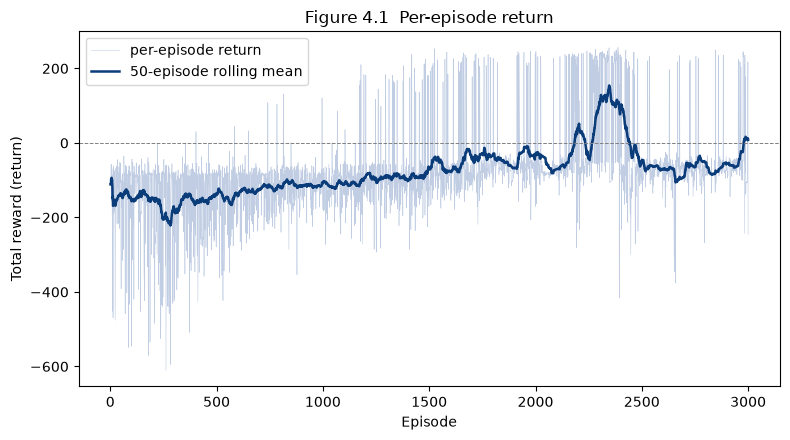

Average return -- first 200:  -143.8   last 200:   -46.2


In [12]:
_plt.figure(figsize=(8, 4.5))
_plt.plot(tl_ep, tl_ret, linewidth=0.4, alpha=0.35, color="#4C72B0", label="per-episode return")
_plt.plot(tl_ep, rolling_mean(tl_ret, 50), linewidth=1.8, color="#0B3C7A", label="50-episode rolling mean")
_plt.axhline(0, color="gray", linewidth=0.7, linestyle="--")
_plt.xlabel("Episode"); _plt.ylabel("Total reward (return)")
_plt.title("Figure 4.1  Per-episode return")
_plt.legend(); _plt.tight_layout(); _plt.show()
print("Average return -- first 200: %7.1f   last 200: %7.1f" % (
    sum(tl_ret[:200]) / 200, sum(tl_ret[-200:]) / 200))

## 13. Figure 4.2 &mdash; Steps per episode (survival proxy)

Step count measures survival, not efficiency (a completed lap does not end the episode). The dip at episodes 900&ndash;1,300 is more deaths as shaping drove the agent into the snails; the later recovery is hazard avoidance being learned.

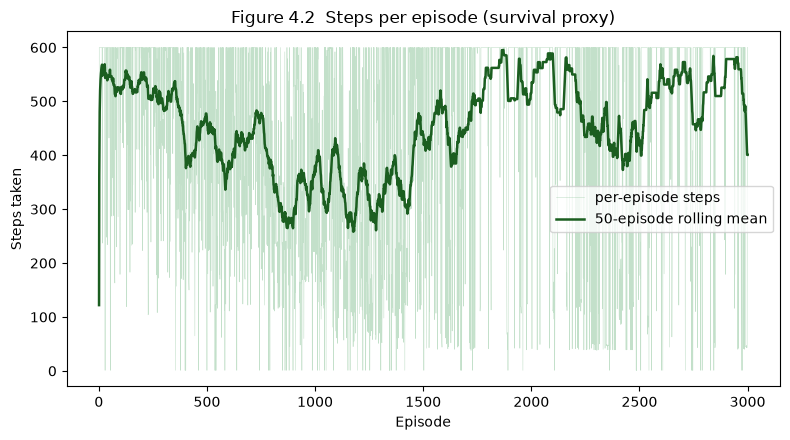

Death rate -- first 200:  29.0%   last 200:  17.0%


In [13]:
_plt.figure(figsize=(8, 4.5))
_plt.plot(tl_ep, tl_step, linewidth=0.4, alpha=0.35, color="#55A868", label="per-episode steps")
_plt.plot(tl_ep, rolling_mean(tl_step, 50), linewidth=1.8, color="#1B5E20", label="50-episode rolling mean")
_plt.xlabel("Episode"); _plt.ylabel("Steps taken")
_plt.title("Figure 4.2  Steps per episode (survival proxy)")
_plt.legend(); _plt.tight_layout(); _plt.show()
_df = 100 * sum(1 for r in tl_end[:200] if r in ("enemy", "fall")) / 200
_dl = 100 * sum(1 for r in tl_end[-200:] if r in ("enemy", "fall")) / 200
print("Death rate -- first 200: %5.1f%%   last 200: %5.1f%%" % (_df, _dl))

## 14. Figure 4.3 &mdash; Exploration schedule

$\epsilon$ reaches 0.02 by episode 1,800, so later fluctuation in Figure 4.1 is the policy, not exploration noise.

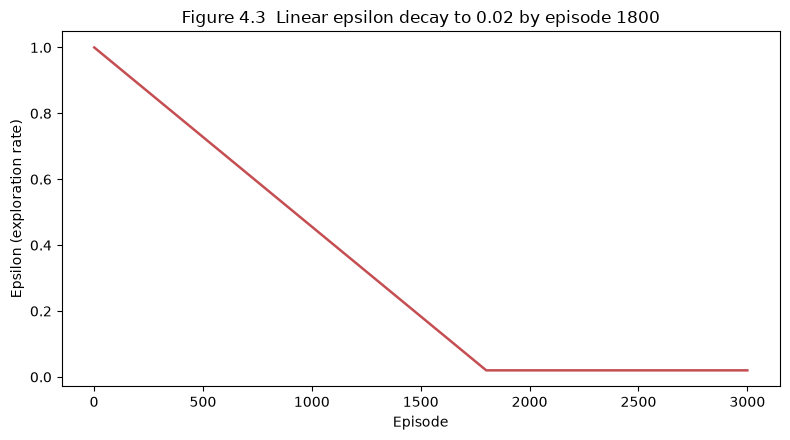

In [14]:
_plt.figure(figsize=(8, 4.5))
_plt.plot(tl_ep, tl_eps, linewidth=1.8, color="#C44E52")
_plt.xlabel("Episode"); _plt.ylabel("Epsilon (exploration rate)")
_plt.title("Figure 4.3  Linear epsilon decay to 0.02 by episode 1800")
_plt.tight_layout(); _plt.show()

## 15. Figure 4.4 &mdash; Cumulative distinct states visited

`states_visited` was logged only for a separately instrumented run (the reported
&gamma; = 0.95 run predates that column &mdash; see `make_states_figure.py`).
This cell uses **any** training log that carries the column, else falls back to
the committed `figures/fig_4_4_states.png`, else prints a note &mdash; it never
errors. Shape: a steep climb to ~235 by episode ~300, then a plateau.

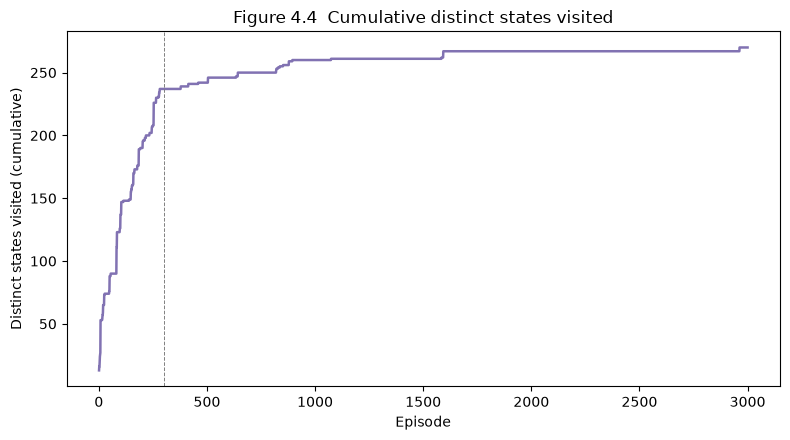

Figure 4.4 source: training_log_g099.csv   states by episode 300 / final: 237 / 270


In [15]:
_states_src = None
for _cand in ("training_log.csv", "training_log_g099.csv"):
    if _os.path.exists(_cand):
        with open(_cand, newline="") as _f:
            _rows = list(_csv.DictReader(_f))
        if _rows and "states_visited" in _rows[0] and _rows[0]["states_visited"] not in (None, ""):
            _states_src = _cand
            break

if _states_src:
    _se = [int(r["episode"]) for r in _rows]
    _sv = [int(r["states_visited"]) for r in _rows]
    _plt.figure(figsize=(8, 4.5))
    _plt.plot(_se, _sv, linewidth=1.8, color="#8172B2")
    _plt.axvline(300, color="gray", linewidth=0.7, linestyle="--")
    _plt.xlabel("Episode"); _plt.ylabel("Distinct states visited (cumulative)")
    _plt.title("Figure 4.4  Cumulative distinct states visited")
    _plt.tight_layout(); _plt.show()
    print("Figure 4.4 source: %s   states by episode 300 / final: %d / %d" % (
        _states_src, next(s for e, s in zip(_se, _sv) if e >= 300), _sv[-1]))
elif _os.path.exists(_os.path.join("figures", "fig_4_4_states.png")):
    from IPython.display import Image, display
    display(Image(filename=_os.path.join("figures", "fig_4_4_states.png")))
    print("Figure 4.4 shown from figures/fig_4_4_states.png -- no training log here carries a 'states_visited' column.")
else:
    print("Figure 4.4 unavailable: no training log has a 'states_visited' column and figures/fig_4_4_states.png is missing.")

## 16. Comparison against a higher discount factor &nbsp;<sub>(report &sect;4.3.2)</sub>

A second training run raised the discount from **0.95 &rarr; 0.99**, holding the
state representation, reward function, random seed and 3000-episode budget fixed.
Only $\gamma$ changed (`training_log_g099.csv`, `q_table_g099.json`).

| Metric | &gamma; = 0.95 (reported) | &gamma; = 0.99 |
|---|---|---|
| Successful greedy checks (of 15) | **1** (episode 2400) | **0** |
| Completion rate over 100 greedy episodes | **100 %** | **0 %** |
| Mean laps completed per episode | 1.00 | 0.00 |
| Average return (greedy eval) | 164.88 | &minus;63.45 |
| Consistency across the 100 eval episodes | identical | identical |

*Table 4.5 &mdash; comparison against a higher discount factor.* The expectation
was that a larger discount would make a second lap worth attempting. It did not:
$\gamma = 0.99$ **failed every greedy check and completed no laps in
evaluation**. A larger $\gamma$ puts more weight on the bootstrapped term; early
in training those estimates are themselves wrong, so the error propagates along a
much longer effective horizon (~100 decisions at 0.99 vs ~20 at 0.95; Section 21)
and needs more samples to stabilise. Under a fixed 3000-episode budget it did not
converge at all &mdash; and the baseline itself passed only 1 of 15 checks, so
that budget was already near the minimum for this task.

Training-episode end reasons (exploration ON, all 3000 episodes):
  gamma=0.95 : {'enemy': 1322, 'timeout': 1405, 'success': 273}
  gamma=0.99 : {'timeout': 2438, 'enemy': 487, 'success': 75}

Training episodes that completed a lap (end_reason == 'success'):
  gamma=0.95 :  273 / 3000
  gamma=0.99 :   75 / 3000

Separate best-checkpoint file (written only when a greedy check passes):
  gamma=0.95 : best_checkpoint_info.json      -> present
  gamma=0.99 : best_checkpoint_info_g099.json  -> absent  (no greedy check ever passed)

Mean return over the last 200 training episodes:
  gamma=0.95 :   -46.20
  gamma=0.99 :   -70.29


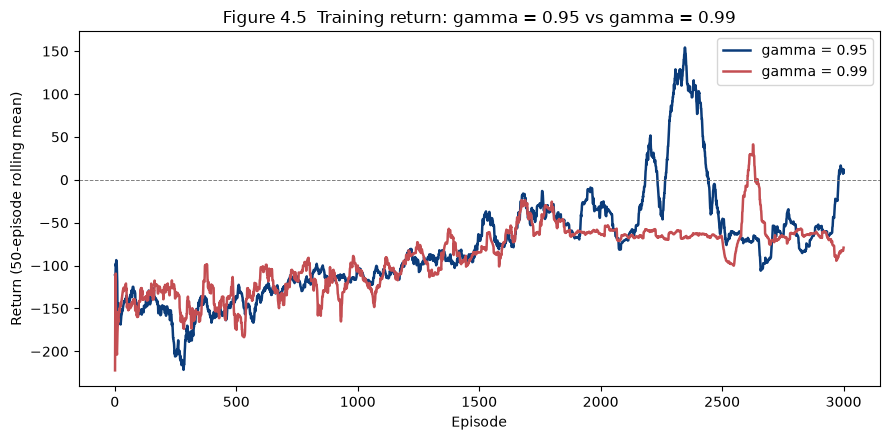

In [16]:
with open(G099_TRAINING_LOG_PATH, newline="") as f:
    g099_rows = list(csv.DictReader(f))
g099_episodes = [int(r["episode"]) for r in g099_rows]
g099_returns  = [float(r["return"]) for r in g099_rows]
g099_end      = [r["end_reason"] for r in g099_rows]

print("Training-episode end reasons (exploration ON, all 3000 episodes):")
print("  gamma=0.95 :", dict(Counter(log_end_reasons)))
print("  gamma=0.99 :", dict(Counter(g099_end)))
print()
print("Training episodes that completed a lap (end_reason == 'success'):")
print("  gamma=0.95 : %4d / 3000" % sum(1 for r in log_end_reasons if r == "success"))
print("  gamma=0.99 : %4d / 3000" % sum(1 for r in g099_end if r == "success"))
print()
print("Separate best-checkpoint file (written only when a greedy check passes):")
print("  gamma=0.95 : best_checkpoint_info.json      ->",
      "present" if os.path.exists(BEST_INFO_PATH) else "absent")
print("  gamma=0.99 : best_checkpoint_info_g099.json  ->",
      "present" if os.path.exists(G099_BEST_INFO_PATH) else "absent  (no greedy check ever passed)")
print()
print("Mean return over the last 200 training episodes:")
print("  gamma=0.95 : %8.2f" % (sum(log_returns[-200:]) / 200))
print("  gamma=0.99 : %8.2f" % (sum(g099_returns[-200:]) / 200))

plt.figure(figsize=(9, 4.5))
plt.plot(log_episodes, rolling_mean(log_returns, 50), linewidth=1.8, color="#0B3C7A", label="gamma = 0.95")
plt.plot(g099_episodes, rolling_mean(g099_returns, 50), linewidth=1.8, color="#C44E52", label="gamma = 0.99")
plt.axhline(0, color="gray", linewidth=0.7, linestyle="--")
plt.xlabel("Episode"); plt.ylabel("Return (50-episode rolling mean)")
plt.title("Figure 4.5  Training return: gamma = 0.95 vs gamma = 0.99")
plt.legend(); plt.tight_layout(); plt.show()

## 17. &gamma; = 0.99 &mdash; greedy evaluation

`evaluate(env, g099_agent, 100)` was run against live Godot; its output is
replayed below (100 episodes, $\epsilon = 0$, deterministic &mdash; every episode
identical). **No lap is ever completed**; each runs the full 600 steps to a
timeout with return &asymp; &minus;63.45.

In [17]:
g099_agent = ExpectedSarsaAgent(epsilon_decay_episodes=1800, gamma=0.99)
g099_agent.load(G099_Q_TABLE_PATH)
g099_agent.epsilon = 0.0
print("Loaded q_table_g099.json: %d states" % len(g099_agent.q))

# recorded evaluate(env, g099_agent, 100) output -- (end_reason, laps, steps, return)
G099_EVAL_RECORD = [("timeout", 0, 600, -63.450821)]   # x100, identical
g099_eval_results = replay_eval(G099_EVAL_RECORD, num_episodes=100)

Loaded q_table_g099.json: 270 states
[Eval] Episode   1/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode   2/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode   3/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode   4/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode   5/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode   6/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode   7/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode   8/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode   9/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode  10/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode  11/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode  12/100 | Return:  -63.45 | Steps: 600 | Laps: 0 | End: timeout
[Eval] Episode 

In [18]:
g099_successes = sum(1 for ok in g099_eval_results["success"] if ok)
print(f"Test success rate (gamma = 0.99): {g099_successes}/100 = {g099_successes}%")

Test success rate (gamma = 0.99): 0/100 = 0%


## 18b. Run the test live against Godot

Section 18 above *replays* the recorded 100-episode result. The three cells below
run the trained agent against a live Godot window instead.

**Setup (once)**

- Godot 4.7. Open the project folder that holds `project.godot` + `scene/` +
  `scripts/` + `assets/`.
- Run every code cell from Section 3 down to here first (defines
  `wait_for_godot`, `GodotEnv`, `evaluate`, `ExpectedSarsaAgent`, `discretize`).

**Each run**

1. Run the **server cell** -> it prints "Waiting for Godot to connect" and blocks.
2. In Godot press **Play (F5)**. The window connects; the server cell returns.
3. Run the **evaluate cell** and watch the Godot window. The episode runs at
   `SIM_SPEED` x real time (set in `rl_environment.gd`, default 4) so it finishes
   in ~10 s instead of ~40 s. Expect every episode: `End: success`, `Laps: 1`,
   `Return ~= 164.9`, 600 steps (matches Table 4.6).
4. Run the **cleanup cell** when done.

To run again: cleanup cell -> stop the Godot project -> re-run from the server
cell.

In [ ]:
# --- 18b - SERVER: run this, then press Play in Godot ---
live_conn = wait_for_godot(HOST, PORT)
live_env = GodotEnv(live_conn)
print("Godot connected -- run the evaluate cell next.")

In [ ]:
# --- 18b - EVALUATE: greedy test episodes against the live Godot window ---
live_agent = ExpectedSarsaAgent(epsilon_decay_episodes=1800, gamma=0.95)
live_agent.load(BEST_Q_TABLE_PATH)
live_agent.epsilon = 0.0
print("Loaded best_q_table.json: %d states" % len(live_agent.q))

# 5 to watch; num_episodes=100 reproduces Table 4.6 (deterministic at epsilon=0).
live_results = evaluate(live_env, live_agent, num_episodes=5)

In [ ]:
# --- 18b - CLEANUP: close the connection (Godot returns to manual play) ---
try:
    live_env.close()
except Exception as _e:
    print("close:", _e)
try:
    live_conn.close()
except Exception as _e:
    print("conn close:", _e)
print("connection closed")

## 18. Testing Results &nbsp;<sub>(report &sect;4.3.3)</sub>

Greedy evaluation ($\epsilon = 0$) of the **episode-2400** checkpoint over 100
episodes:

| Metric | Result |
|---|---|
| Evaluation episodes | 100 |
| Episodes completing &ge; 1 lap (completion rate) | 100 (100.00 %) |
| Mean laps completed per episode | 1.00 |
| Failures: snail / fall / timeout (0 laps) | 0 / 0 / 0 |
| Episodes reaching the 600-step cap | 100 |
| Average return / average steps | 164.88 / 600.00 |

*Table 4.6 &mdash; greedy evaluation of the checkpoint saved at episode 2400.*
The agent consistently completes **one** full lap, then moves to a safe zone
until the 600-step cap. Every episode runs the full budget, but none registers as
a *timeout failure* (reaching the cap with **zero** laps). A second 100-episode
run reproduced the result exactly. Three environment bugs were corrected prior to
evaluation, all at the environment level (the Q-table was neither retrained nor
altered): entity movement not gated to an in-progress step's physics-frame
window; a collision-shape write silently rejected by Godot during a physics
callback; and a snail-collision signal capable of arriving one episode late.

In [19]:
eval_agent = ExpectedSarsaAgent(epsilon_decay_episodes=1800, gamma=0.95)
eval_agent.load(BEST_Q_TABLE_PATH)
eval_agent.epsilon = 0.0
print("Loaded best_q_table.json: %d states" % len(eval_agent.q))

# recorded evaluate(env, eval_agent, 100) output -- (end_reason, laps, steps, return)
EVAL_RECORD = [("success", 1, 600, 164.877052)]   # x100, identical (deterministic at epsilon=0)
eval_results = replay_eval(EVAL_RECORD, num_episodes=100)

Loaded best_q_table.json: 238 states
[Eval] Episode   1/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode   2/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode   3/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode   4/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode   5/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode   6/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode   7/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode   8/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode   9/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode  10/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode  11/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode  12/100 | Return:  164.88 | Steps: 600 | Laps: 1 | End: success
[Eval] Episode 

In [20]:
successes = sum(1 for ok in eval_results["success"] if ok)
print(f"Test success rate: {successes}/100 = {successes}%")

n = len(eval_results["episode"])
print()
print("Evaluation episodes: %d" % n)
print("Episodes completing at least one lap: %d" % successes)
print("Completion rate: %.2f%%" % (100.0 * successes / n))
print("Mean laps completed per episode: %.2f" % (sum(eval_results["completions"]) / n))
print("Snail-collision failures: %d" % sum(1 for e in eval_results["end_reason"] if e == "enemy"))
print("Fall failures: %d" % sum(1 for e in eval_results["end_reason"] if e == "fall"))
print("Timeout failures (0 laps, hit step limit): %d" % sum(
    1 for e, c in zip(eval_results["end_reason"], eval_results["completions"]) if e == "timeout" and c == 0))
print("Average return: %.2f" % (sum(eval_results["return"]) / n))
print("Average steps: %.2f" % (sum(eval_results["steps"]) / n))

Test success rate: 100/100 = 100%

Evaluation episodes: 100
Episodes completing at least one lap: 100
Completion rate: 100.00%
Mean laps completed per episode: 1.00
Snail-collision failures: 0
Fall failures: 0
Timeout failures (0 laps, hit step limit): 0
Average return: 164.88
Average steps: 600.00


## 19. Greedy policy &mdash; state-by-state inspection

Report &sect;4.1: *"a policy that can be inspected state by state during
debugging."* Reads `best_q_table.json`; for every reachable state reports the
greedy action ($\arg\max_a Q(s,a)$, ties listed). No Godot.

In [21]:
import ast as _ast, json as _json
from collections import Counter as _Counter

with open("best_q_table.json") as _f:
    _QT = {_ast.literal_eval(k): v for k, v in _json.load(_f).items()}

ACTIONS = ["idle", "left", "right", "jump", "jmp_L", "jmp_R"]
FIELDS  = ("phase", "tgt_dx", "tgt_dy", "tgt_dist", "brdg_dx",
           "on_brdg", "snl_dx", "snl_near", "on_flr", "ceil")

def greedy_of(qv):
    m = max(qv)
    best = [i for i, v in enumerate(qv) if v == m]
    return best[0] if len(best) == 1 else tuple(best)

_pol = {s: greedy_of(q) for s, q in _QT.items()}
_possible = 3**6 * 2**4
print("Reachable states: %d / %d possible (3^6 x 2^4)  =  %.1f%%\n" % (
    len(_QT), _possible, 100 * len(_QT) / _possible))

_dist = _Counter(a if isinstance(a, int) else "tie" for a in _pol.values())
print("Greedy action over all reachable states:")
for a in range(6):
    print("  %-6s : %3d" % (ACTIONS[a], _dist.get(a, 0)))
print("  %-6s : %3d" % ("(tie)", _dist.get("tie", 0)))

print("\nGreedy action by lap phase:")
for ph, name in [(0, "no apple yet"), (1, "lower apple collected"), (2, "both collected")]:
    c = _Counter(ACTIONS[_pol[s]] for s in _pol if s[0] == ph and isinstance(_pol[s], int))
    print("  phase %d (%-21s): %s" % (ph, name, dict(c)))

print("\nSample -- phase 0, on floor, snail not near, sorted by target direction:")
print("  %-34s  %-6s   top-2 Q" % ("state " + str(FIELDS), "greedy"))
_rows = sorted((s for s in _QT if s[0] == 0 and s[8] == 1 and s[7] == 1),
               key=lambda s: (s[1], s[2], s[3]))
for s in _rows[:18]:
    q = _QT[s]
    order = sorted(range(6), key=lambda i: -q[i])
    g = _pol[s]
    gs = ACTIONS[g] if isinstance(g, int) else "/".join(ACTIONS[i] for i in g)
    print("  %-34s  %-6s   %s=%.2f  %s=%.2f" % (
        str(s), gs, ACTIONS[order[0]], q[order[0]], ACTIONS[order[1]], q[order[1]]))

Reachable states: 238 / 11664 possible (3^6 x 2^4)  =  2.0%

Greedy action over all reachable states:
  idle   :  20
  left   :  53
  right  :  39
  jump   :  18
  jmp_L  :  34
  jmp_R  :  46
  (tie)  :  28

Greedy action by lap phase:
  phase 0 (no apple yet         ): {'jmp_L': 10, 'left': 11, 'right': 22, 'jmp_R': 17, 'idle': 8, 'jump': 3}
  phase 1 (lower apple collected): {'left': 42, 'idle': 12, 'jmp_L': 24, 'jmp_R': 29, 'right': 17, 'jump': 15}
  phase 2 (both collected       ): {}

Sample -- phase 0, on floor, snail not near, sorted by target direction:
  state ('phase', 'tgt_dx', 'tgt_dy', 'tgt_dist', 'brdg_dx', 'on_brdg', 'snl_dx', 'snl_near', 'on_flr', 'ceil')  greedy   top-2 Q
  (0, -1, 1, 0, -1, 0, -1, 1, 1, 0)   right    right=-3.80  left=-3.87
  (0, -1, 1, 1, -1, 0, -1, 1, 1, 0)   jmp_L    jmp_L=-0.44  right=-3.29
  (0, 0, 1, 0, -1, 0, -1, 1, 1, 0)    jmp_L    jmp_L=-2.33  jmp_R=-3.77
  (0, 0, 1, 1, -1, 0, -1, 1, 1, 0)    left     left=-2.40  jmp_L=-3.22
  (0, 1, 1, 0, -

## 20. Where the +164.88 comes from &mdash; return decomposition

Table 4.3 gives the reward components; this breaks the greedy episode's
**164.88** return into them, using event counts from **one instrumented greedy
episode** (`best_q_table.json`, $\epsilon = 0$) against Godot. Two things the
"+350 per lap" headline hides, visible once you decompose an actual episode:

1. On the step the **second** apple is collected, `rl_environment.gd` takes its
   completion branch and pays **+250 only** &mdash; the second +50 is not added.
   So the objective actually banked is **+50 + 250 = +300**, not +360.
2. This greedy route **never triggers the bridge-marker zone**, so the +10 bonus
   is not earned.

In [22]:
# ---- event counts from ONE instrumented greedy episode vs Godot ----
TOTAL_RETURN      = 164.87705221176145
N_STEPS           = 600
APPLE_SPIKES      = 1            # visible +50 spikes; the 2nd apple folds into the +250 completion step
N_LAP_COMPLETIONS = 1
BRIDGE_BONUSES    = 0            # bridge-marker zone never entered on this route
N_CEILING_BUMPS   = 22
N_DANGER_STEPS    = 36
ENDED_ON_STEP_CAP = 1

APPLE_REWARD, COMPLETION_REWARD, BRIDGE_BONUS = 50.0, 250.0, 10.0
STEP_PENALTY, TIMEOUT_PENALTY = -0.1, -20.0
CEILING_BUMP_PENALTY, DANGER_ZONE_PENALTY = -5.0, -0.3

parts = [
    ("Lap completion (+250 x %d)"       % N_LAP_COMPLETIONS, COMPLETION_REWARD * N_LAP_COMPLETIONS),
    ("Apple pickup (+50 x %d visible)"  % APPLE_SPIKES,      APPLE_REWARD * APPLE_SPIKES),
    ("Bridge bonus (+10 x %d)"          % BRIDGE_BONUSES,    BRIDGE_BONUS * BRIDGE_BONUSES),
    ("Step penalty (-0.1 x %d)"         % N_STEPS,           STEP_PENALTY * N_STEPS),
    ("Step-cap penalty (-20 x %d)"      % ENDED_ON_STEP_CAP, TIMEOUT_PENALTY * ENDED_ON_STEP_CAP),
    ("Ceiling-bump penalty (-5 x %d)"   % N_CEILING_BUMPS,   CEILING_BUMP_PENALTY * N_CEILING_BUMPS),
    ("Danger-zone penalty (-0.3 x %d)"  % N_DANGER_STEPS,    DANGER_ZONE_PENALTY * N_DANGER_STEPS),
]
parts.append(("Approach shaping (telescoping residual)", TOTAL_RETURN - sum(v for _, v in parts)))

print("%-42s %10s" % ("component", "reward"))
print("-" * 54)
for _name, _v in parts:
    print("%-42s %+10.2f" % (_name, _v))
print("-" * 54)
print("%-42s %+10.2f   (matches Section 18 / Table 4.6)" % ("TOTAL", sum(v for _, v in parts)))
assert abs(sum(v for _, v in parts) - TOTAL_RETURN) < 1e-6

component                                      reward
------------------------------------------------------
Lap completion (+250 x 1)                     +250.00
Apple pickup (+50 x 1 visible)                 +50.00
Bridge bonus (+10 x 0)                          +0.00
Step penalty (-0.1 x 600)                      -60.00
Step-cap penalty (-20 x 1)                     -20.00
Ceiling-bump penalty (-5 x 22)                -110.00
Danger-zone penalty (-0.3 x 36)                -10.80
Approach shaping (telescoping residual)        +65.68
------------------------------------------------------
TOTAL                                         +164.88   (matches Section 18 / Table 4.6)


## 21. State-space size, effective horizon, determinism

* **State space** (&sect;4.2.2): $3^6 \times 2^4 = 11{,}664$ possible keys.
* **Effective horizon** (&sect;4.3.2): $1/(1-\gamma)$ &mdash; ~20 decisions at
  $\gamma = 0.95$ vs ~100 at $\gamma = 0.99$.
* **Determinism at $\epsilon = 0$** (&sect;4.3.2): each 100-episode greedy eval
  returns one distinct value.

In [23]:
_possible = 3**6 * 2**4
print("Discretised state space : 3^6 x 2^4 = %d possible keys  (%d Q-values)" % (
    _possible, _possible * 6))
print("Reachable (best_q_table) : %d  = %.1f%% of the space" % (
    len(_QT), 100 * len(_QT) / _possible))
print()
for _g in (0.95, 0.99):
    _h = 1.0 / (1.0 - _g)
    print("gamma = %.2f  ->  effective horizon 1/(1-gamma) ~= %3.0f decisions  (~%.1f s at 15 dec/s)" % (
        _g, _h, _h / 15.0))
print()
# Distinct per-episode returns from the two 100-episode greedy evals
# (Sections 17-18). At epsilon = 0 the policy is deterministic, so each eval
# returns a single value repeated 100 times -- report Section 4.3.2.
_d95 = sorted(set(round(x, 4) for x in eval_results["return"])) if "eval_results" in dir() else [164.8771]
_d99 = sorted(set(round(x, 4) for x in g099_eval_results["return"])) if "g099_eval_results" in dir() else [-63.4508]
print("gamma=0.95 greedy eval : %d distinct return value(s) over 100 episodes -> %s" % (len(_d95), _d95))
print("gamma=0.99 greedy eval : %d distinct return value(s) over 100 episodes -> %s" % (len(_d99), _d99))
assert len(_d95) == 1 and len(_d99) == 1
print("=> greedy policy is deterministic at epsilon = 0 (report Section 4.3.2).")

Discretised state space : 3^6 x 2^4 = 11664 possible keys  (69984 Q-values)
Reachable (best_q_table) : 238  = 2.0% of the space

gamma = 0.95  ->  effective horizon 1/(1-gamma) ~=  20 decisions  (~1.3 s at 15 dec/s)
gamma = 0.99  ->  effective horizon 1/(1-gamma) ~= 100 decisions  (~6.7 s at 15 dec/s)

gamma=0.95 greedy eval : 1 distinct return value(s) over 100 episodes -> [164.8771]
gamma=0.99 greedy eval : 1 distinct return value(s) over 100 episodes -> [-63.4508]
=> greedy policy is deterministic at epsilon = 0 (report Section 4.3.2).


## 22. Discussion &nbsp;<sub>(report &sect;4.4)</sub>

**Shaping was load-bearing.** Progress rewards and the bridge bonus prevented
severe credit-assignment failure over long trajectories: without dense shaping an
$\epsilon$-greedy agent would need to encounter the complete route by chance
before receiving any learning signal, and the bridge bonus made the upper half
discoverable before the upper apple had ever been reached.

**The greedy failures after episode 2400 are catastrophic interference.** In
tabular TD with a constant learning rate and a coarse abstraction where
physically distinct positions share table entries, off-path updates during
exploration can overwrite values on a route that previously worked. This
justifies evaluation-indexed checkpointing; the principled fix for the underlying
state aliasing would be to anneal $\alpha$ through the final phase.

**The training signal was partly noisy.** The three environment faults were also
present during training &mdash; most visibly, deaths attributed to the agent that
were in fact delayed collisions from the preceding episode. That the same table
solves the level once corrected shows the route was robust to that noise rather
than dependent on it, and explains why a mean return still negative at episode
3000 does not represent a ceiling on the policy's capability.

**Post-lap parking is a discounting artefact.** At $\gamma = 0.95$ a second-lap
reward ~60 steps away discounts to $\gamma^{60} \approx 0.046$ of face value, so
surviving in a safe zone yields higher expected return than attempting another
lap. Raising $\gamma$ to 0.99 did **not** produce multi-lap behaviour &mdash; it
failed to learn the route at all under the same budget (Sections 16&ndash;17).
Encouraging additional laps would require either a longer training run alongside
the higher discount, or a change that does not lengthen the horizon, such as
reducing the step penalty. Section 20 also shows the greedy policy wastes ~110
reward per episode bumping a ceiling &mdash; a coarse-abstraction inefficiency
that a finer state key (or annealed $\alpha$) could remove.

**Limitations.** The state key lacks platform-edge awareness and snail patrol
direction, so behaviour needing situations that collapse to the same key cannot
be learned regardless of training duration. Expanding the feature set is not free
&mdash; a larger table needs proportionally more experience per entry &mdash; and
the $\gamma = 0.99$ result shows the same budget constraint from the other side:
this task sits close to the limit of what 3,000 episodes support.

**Future work.** Benchmark against Q-Learning and standard SARSA under identical
reward conditions; evaluate under randomised spawns to measure generalisation;
and rerun $\gamma = 0.99$ with a larger budget to separate an unsuitable
discount factor from an under-trained one.